# Import des librairies

In [27]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np


from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

from collections import Counter
from tqdm import tqdm


#import locaux

from import_dataset import load_dataset
from explore_data import downsample_data, plot_xy_grid, plot_3d, txt_to_df
from Edit_distance import edit_distance

# Chargement des Datasets

In [28]:
#BASE_DIR = os.path.dirname(os.path.abspath(__file__)) le __file__ fait planter le code dans un script python, mais dans un notebook il n'est pas défini, du coup on utilise os.getcwd() pour prendre le répertoire courant du notebook
BASE_DIR = os.getcwd()
DATA_DIR_DOMAIN1 = os.path.join(BASE_DIR, "Dataset", "Domain1_csv")
DATA_DIR_DOMAIN4 = os.path.join(BASE_DIR,"Dataset", "Domain4_csv")

#print(len(os.listdir(DATA_DIR))) validation que tous les chiffiers ont été chargés

dataset_domain1 = pd.concat(load_dataset(DATA_DIR_DOMAIN1), ignore_index=True) 

print(f"{len(dataset_domain1)} fichiers chargés .") 
print(f"Dimension du dataset : {dataset_domain1.shape}")

print(dataset_domain1.head())

# ligne a décommenter pour sauvegarder le dataset traité dans un fichier csv
#dataset_domain1.to_csv(os.path.join(BASE_DIR, "Dataset", "Aggregated_csv", "Domain1_processed_dataset.csv"), index=False) 


85095 fichiers chargés .
Dimension du dataset : (85095, 7)
          x         y         z      t  subject_id  digit  repetition
0  0.042075  0.036799  0.258380    6.0           1      0           1
1  0.041904  0.037187  0.258505   37.0           1      0           1
2  0.041739  0.037219  0.258619   67.0           1      0           1
3  0.041446  0.037573  0.258731  101.0           1      0           1
4  0.041303  0.037331  0.258830  132.0           1      0           1


# Sous-échantillonnage et visualisation 

## Domain 1


Sous-echantillonnage des données...


C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\2644263587.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_domain1.groupby(['subject_id', 'digit', 'repetition'])


Terminé !
Points originaux     : 85,095
Points sous-échant.  : 49,437
Réduction effective  : 41.9%
=== BILAN DU PRÉ-TRAITEMENT ===
Points (coordonnées) : 85,095 -> 49,437 (41.9% de réduction)
Gestes (séquences)   : 1000 -> 1000 (Conservation: 100.0%)
 Succès : Tous les gestes ont été conservés.
Subject ID: 1, Digit: 0, Number of rows: 127
Subject ID: 1, Digit: 0, Number of rows: 128
Subject ID: 1, Digit: 0, Number of rows: 172
Subject ID: 1, Digit: 0, Number of rows: 98
Subject ID: 1, Digit: 0, Number of rows: 117
Subject ID: 1, Digit: 0, Number of rows: 110
Subject ID: 1, Digit: 0, Number of rows: 109
Subject ID: 1, Digit: 0, Number of rows: 118
Subject ID: 1, Digit: 0, Number of rows: 107
Subject ID: 1, Digit: 0, Number of rows: 118


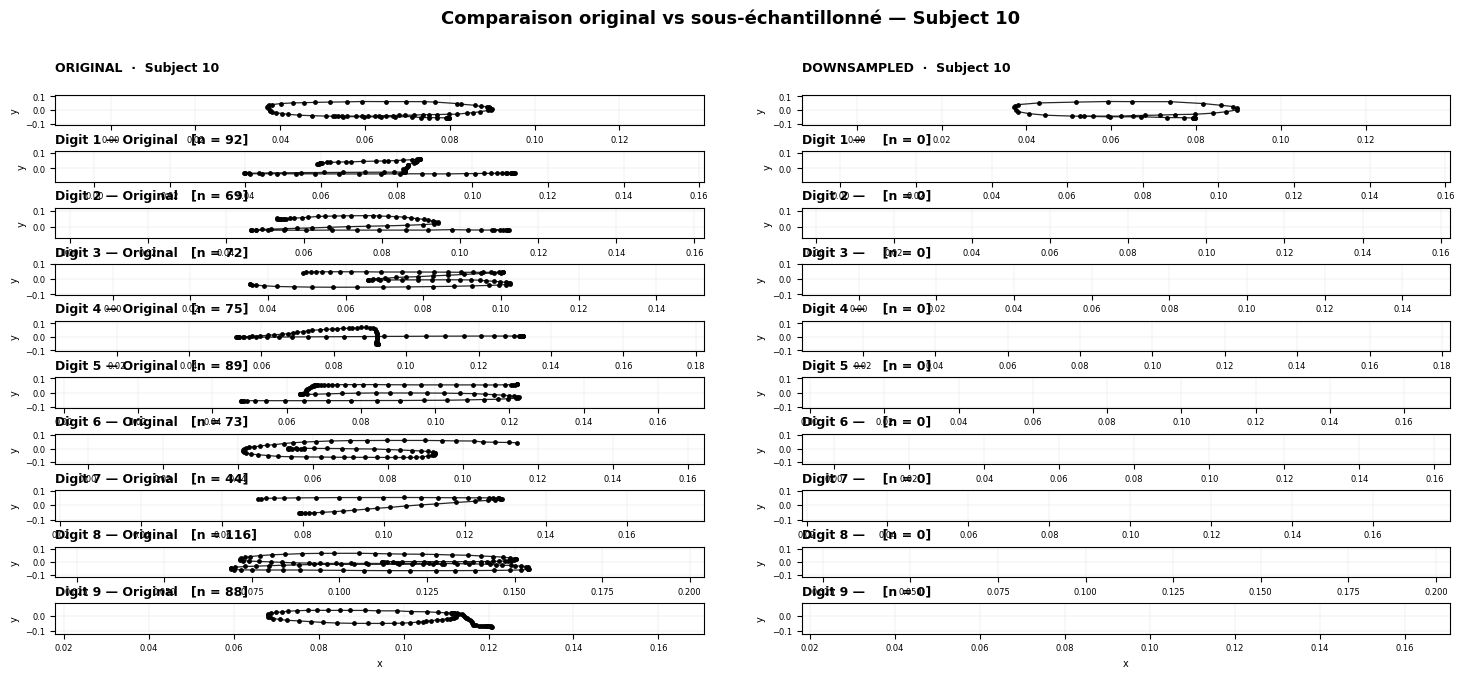

Affichage terminé.


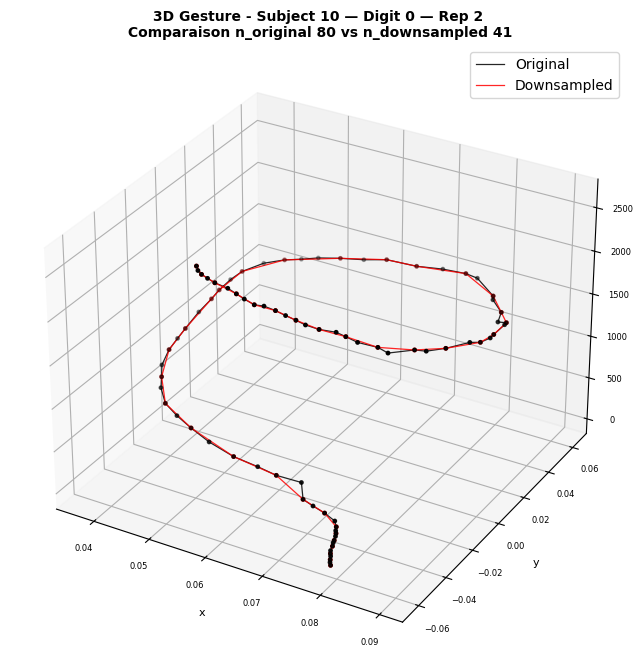

Affichage 3D terminé.


In [29]:
df_domain1 = dataset_domain1.copy() # pour éviter de modifier le dataset original

print("Sous-echantillonnage des données...")

df_domain1_downsampled = (
    df_domain1.groupby(['subject_id', 'digit', 'repetition']) 
    .apply(downsample_data)
    .reset_index(drop=True)
)

original_count = len(df_domain1) 
downsampled_count = len(df_domain1_downsampled)
reduction = (1-downsampled_count/original_count)*100

print(f"Terminé !")
print(f"Points originaux     : {original_count:,}")
print(f"Points sous-échant.  : {downsampled_count:,}")
print(f"Réduction effective  : {reduction:.1f}%")

# 2. Calcul des gestes (combinaisons uniques sujet/digit/rep)
def count_gestures(df):
    return len(df.groupby(['subject_id', 'digit', 'repetition']))

old_gestures = count_gestures(df_domain1)
new_gestures = count_gestures(df_domain1_downsampled)

print(f"=== BILAN DU PRÉ-TRAITEMENT ===")
print(f"Points (coordonnées) : {original_count:,} -> {downsampled_count:,} ({reduction:.1f}% de réduction)")
print(f"Gestes (séquences)   : {old_gestures} -> {new_gestures} (Conservation: {(new_gestures/old_gestures)*100:.1f}%)")

if old_gestures == new_gestures:
    print(" Succès : Tous les gestes ont été conservés.")
else:
    print(f" Attention : {old_gestures - new_gestures} geste(s) perdu(s).")

# ligne a décommenter pour sauvegarder le dataset traité dans un fichier csv
#df_domain1_downsampled.to_csv(os.path.join(BASE_DIR, "Dataset", "Domain1_aggregated_csv", "Domain1_downsampled_dataset.csv"), index=False)

# prendre un subset 
subset = df_domain1[(df_domain1['subject_id'] == 1) & (df_domain1['digit'] == 0)]

for (subject_id, digit,rep), group in subset.groupby(['subject_id', 'digit', 'repetition']):
   print(f"Subject ID: {subject_id}, Digit: {digit}, Number of rows: {len(group)}")


# code pour afficher les points avant et après le sous-échantillonnage pour un groupe spécifique (par exemple, subject_id=1, digit=0)

plot_xy_grid(df = df_domain1, df_downsampled= df_domain1_downsampled, subject=10)

plot_3d(df= df_domain1, df_downsampled=df_domain1_downsampled, subject=10, digit=0)


## Domain 4

A noter pas run pour le moment dataset de base pas encore décorté

In [ ]:
df_domain4 = dataset_domain4.copy() # pour éviter de modifier le dataset original

print("Sous-echantillonnage des données...")

df_domain4_result = (
    df_domain4.groupby(['subject_id', 'digit', 'repetition']) 
    .apply(downsample_data)
    .reset_index(drop=True)
)

df_domain4_downsampled = df_domain4_result[df_domain4_result['downsampled'] == True].drop(columns=['downsampled'])

original_count = len(df_domain4) 
downsampled_count = len(df_domain4_downsampled)
reduction = (1-downsampled_count/original_count)*100

print(f"Terminé !")
print(f"Points originaux     : {original_count:,}")
print(f"Points sous-échant.  : {downsampled_count:,}")
print(f"Réduction effective  : {reduction:.1f}%")

# --- Vérification par groupe ---
summary = df_domain4.groupby(["subject_id", "digit", "repetition"]).size().reset_index(name="n_original")
summary_new = df_domain4_downsampled.groupby(["subject_id", "digit", "repetition"]).size().reset_index(name="n_downsampled")

summary["was_downsampled"] = df_domain4_result.groupby(["subject_id", "digit", "repetition"])["downsampled"].first().values

summary = summary.merge(summary_new, on=["subject_id", "digit", "repetition"])
summary["ratio"] = summary["n_downsampled"] / summary["n_original"]

skipped = (~summary["was_downsampled"]).sum()
print("\n Aperçu des ratios de réduction par groupe :")
print(summary.describe())

# ligne a décommenter pour sauvegarder le dataset traité dans un fichier csv
#df_domain1_downsampled.to_csv(os.path.join(BASE_DIR, "Dataset", "Domain1_aggregated_csv", "Domain1_downsampled_dataset.csv"), index=False)

# prendre un subset 
subset = df_domain4[(df_domain4['subject_id'] == 1) & (df_domain4['digit'] == 0)]

for (subject_id, digit,rep), group in subset.groupby(['subject_id', 'digit', 'repetition']):
   print(f"Subject ID: {subject_id}, Digit: {digit}, Number of rows: {len(group)}")


# code pour afficher les points avant et après le sous-échantillonnage pour un groupe spécifique (par exemple, subject_id=1, digit=0)

Subject = 1 
Line_color = 'black'

Digits = sorted(df_domain4['digit'].unique())
N_rows = len(Digits)
N_columns = 2

plot_xy_grid(df=df_domain4,subject=10)

plot_3d(df=df_domaine4subject=10, digit=0)


: 

# Prepocessing 

In [30]:
print("Standardisation individuelle des gestes en cours...")

# 1. La standardisation PAR GESTE 
def standardize_group(group):
    coords = group[['x', 'y', 'z']].values 
    gravity_center = np.mean(coords, axis=0)
    std = np.std(coords, axis=0)
    std[std == 0] = 1 # Sécurité pour éviter la division par zéro
    
    coords_std = (coords - gravity_center) / std
    
    # On ajoute directement les colonnes au groupe
    group['x_std'] = coords_std[:, 0]
    group['y_std'] = coords_std[:, 1]
    group['z_std'] = coords_std[:, 2]
    return group

# On l'applique sur chaque geste du df_downsampled et df initial

df_domain1_downsampled = df_domain1_downsampled.groupby(['subject_id', 'digit', 'repetition'], group_keys=False).apply(standardize_group) 
df_domain1 = df_domain1.groupby(['subject_id', 'digit', 'repetition'], group_keys=False).apply(standardize_group) 

# 2. Extraction des points 
points_3d_downsampled = df_domain1_downsampled[['x_std', 'y_std', 'z_std']].values # on prend les colonnes standardisées pour faire du clustering
points_3d = df_domain1[['x_std', 'y_std', 'z_std']].values

print(f"Prêt ! {points_3d_downsampled.shape[0]} points 3D downsampled vont être analysés pour le domaine 1.")
print(f"Prêt ! {points_3d.shape[0]} points 3D vont être analysés pour le domaine 1.")

# ============================================================
# Train / Test Split
# ============================================================

# Features: les coordonnées 3D standardisées (x_std, y_std, z_std)
# Labels: la colonne 'digit' qui représente le geste

def split_dataset(df):
    X = df[['x_std', 'y_std', 'z_std']].values  # Features: points 3D standardisés
    y = df['digit'].values

    print(f"\n=== Train/Test Split ===")
    print(f"Features (X): shape = {X.shape}")
    print(f"Labels (y): shape = {y.shape}")
    print(f"Classes uniques: {np.unique(y)}")

    #  Split avec stratification sur les labels pour maintenir la distribution des classes
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2,  # 80% train, 20% test
        random_state=42,  # Pour reproductibilité
        stratify=y  # Maintenir la proportion des classes
    )

    print(f"\nTrain set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")
    print(f"\nDistribution des classes dans train:")
    print(Counter(y_train))
    print(f"\nDistribution des classes dans test:")
    print(Counter(y_test))

    return X_train,X_test,y_train,y_test

X_train_domain1,X_test_domain1,y_train_domain1,y_test_domain1 = split_dataset(df_domain1)

X_train_domain1_downsampled,X_test_domain1_downsampled ,y_train_domain1_downsampled ,y_test_domain1_downsampled = split_dataset(df_domain1_downsampled)


Standardisation individuelle des gestes en cours...


C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\3830994675.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_domain1_downsampled = df_domain1_downsampled.groupby(['subject_id', 'digit', 'repetition'], group_keys=False).apply(standardize_group)


Prêt ! 49437 points 3D downsampled vont être analysés pour le domaine 1.
Prêt ! 85095 points 3D vont être analysés pour le domaine 1.

=== Train/Test Split ===
Features (X): shape = (85095, 3)
Labels (y): shape = (85095,)
Classes uniques: [0 1 2 3 4 5 6 7 8 9]

Train set: 68076 samples
Test set: 17019 samples

Distribution des classes dans train:
Counter({np.int64(8): 8653, np.int64(1): 7510, np.int64(0): 7470, np.int64(5): 7058, np.int64(9): 6992, np.int64(3): 6950, np.int64(4): 6773, np.int64(6): 6408, np.int64(2): 6120, np.int64(7): 4142})

Distribution des classes dans test:
Counter({np.int64(8): 2163, np.int64(1): 1877, np.int64(0): 1867, np.int64(5): 1765, np.int64(9): 1748, np.int64(3): 1738, np.int64(4): 1693, np.int64(6): 1602, np.int64(2): 1530, np.int64(7): 1036})

=== Train/Test Split ===
Features (X): shape = (49437, 3)
Labels (y): shape = (49437,)
Classes uniques: [0 1 2 3 4 5 6 7 8 9]

Train set: 39549 samples
Test set: 9888 samples

Distribution des classes dans train:


C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\3830994675.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_domain1 = df_domain1.groupby(['subject_id', 'digit', 'repetition'], group_keys=False).apply(standardize_group)


# Edit-Distance

## Clustering - Analyse nombre de cluster par la Méthode du coude

Elbow - Domain 1 full dataset
K-Means : Test des k de 2 à 30 ...


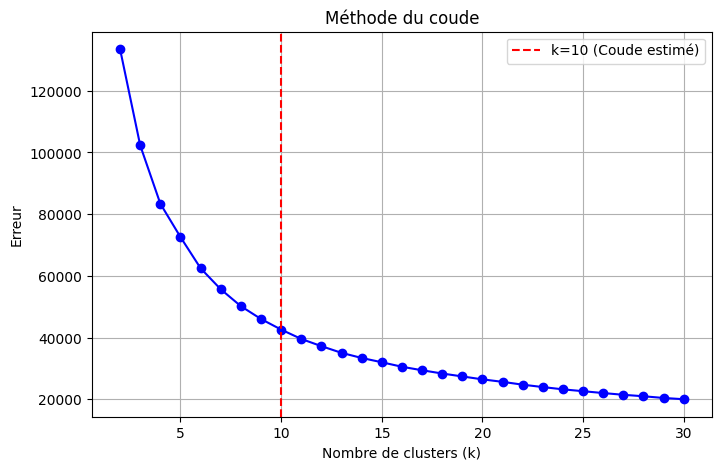

Elbow - Domain 1 downsampled
K-Means : Test des k de 2 à 30 ...


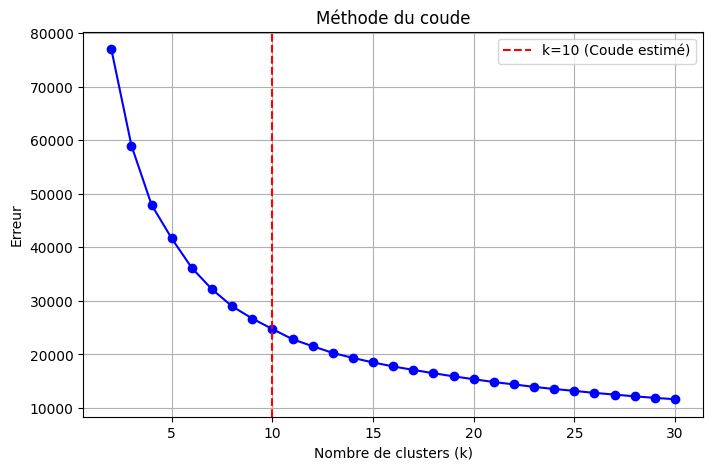

In [6]:

# 3. Méthode du coude
def plot_elbow_method(X, max_k=30): 
    errors = []
    k_values = range(2, max_k + 1)
    
    print(f"K-Means : Test des k de 2 à {max_k} ...")
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X) 
        errors.append(kmeans.inertia_) # inertia_ est la somme des distances au carré entre les points et leur centre de cluster (plus c'est bas, mieux c'est)

    plt.figure(figsize=(8,5))
    plt.plot(k_values, errors, marker='o', color='b')
    
    # On ajoute une ligne pointillée sur k=10 pour le mettre en évidence
    plt.axvline(x=10, color='r', linestyle='--', label='k=10 (Coude estimé)')
    
    plt.title('Méthode du coude')
    plt.xlabel('Nombre de clusters (k)')
    plt.ylabel("Erreur")
    plt.legend()
    plt.grid(True)
    plt.show()

print("Elbow - Domain 1 full dataset")
plot_elbow_method(X_train_domain1)

print("Elbow - Domain 1 downsampled")
plot_elbow_method(X_train_domain1_downsampled)


Méthode du coude peu efficace donc on va tester l'hyperparametre k pour visualiser quelle valeur de k prévue entre 10 et 20 inclus par pas de 2 maximise l'accuracy du classifieur complèt k-NN sur base de l'edit distance. 

### Traduction des clusters en alphabet

In [31]:
print("Création de l'alphabet et traduction...")

# 1. Entraînement du modèle définitif avec le k=10 (choisi à partir de la méthode du coude)
k_optimal = 10 #(encore à tester)


print(f"Apprentissage des {k_optimal} lettres de l'alphabet spatial...")

def kMeans_application(X_train, k_optimal):
    kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
    kmeans_final.fit(X_train)

    #centroids = kmeans_final.cluster_centers_
    #print(centroids) #print un tableau de forme (n_clusters,3) avec les 2 coordonées (x,y,z) de chaque centroide 
    # a récupérer pour le test

    return kmeans_final


kmeans_final_domain1 = kMeans_application(X_train_domain1,14) # 14 a modifier

kmeans_final_domain1_downsampled = kMeans_application(X_train_domain1_downsampled,14) # 14 a modifier


# 2. La fonction de traduction (de points 3D vers du Texte)
def traduire_en_lettres(group,kmeans_final):
    # On extrait les points standardisés du geste
    coords = group[['x_std', 'y_std', 'z_std']].values
    
    # Le K-Means attribue chaque point à son cluster le plus proche (de 0 à 12)
    labels = kmeans_final.predict(coords)
    
    # On transforme le numéro en lettre (0 -> A, 1 -> B, ..., 12 -> M)
    # L'astuce : chr(65) donne 'A' en informatique (code ASCII)
    lettres = [chr(65 + label) for label in labels]
    
    # On colle toutes les lettres pour faire un seul mot (ex: "AABBCCC...")
    mot = "".join(lettres)
    
    # On retourne une petite boîte contenant notre mot
    return pd.Series({'mot_traduit': mot})

print("Traduction des gestes en texte ...")

# 3. Application de la traduction geste par geste
# utilisation de groupby pour ne pas mélanger les gestes !
df_domain1_downsampled_mots = df_domain1_downsampled.groupby(['subject_id', 'digit', 'repetition']).apply(traduire_en_lettres,kmeans_final=kmeans_final_domain1_downsampled).reset_index()

#groupby créer déjà les sous-groupes donc pas besoin de le spécifier dans traduire_en_lettres.

df_domain1_mots = df_domain1.groupby(['subject_id', 'digit', 'repetition']).apply(traduire_en_lettres,kmeans_final = kmeans_final_domain1).reset_index()

# 4. Sauvegarde du Dictionnaire Final
output_dir = os.path.join(BASE_DIR, "Dataset", "Aggregated_csv")
os.makedirs(output_dir, exist_ok=True)

output_path_downsampled = os.path.join(output_dir, "Domain1_dictionnaire_mots_downsampled.csv")
output_path = os.path.join(output_dir, "Domain1_dictionnaire_mots.csv")

# to uncomment if dictionnary exported
df_domain1_downsampled_mots.to_csv(output_path_downsampled, index=False)
df_domain1_mots.to_csv(output_path, index=False)

print(f"Terminé ! Le dictionnaire downsampled est sauvegardé ici : {output_path_downsampled}")
print("\n Aperçu des données (prêtes pour l'Edit Distance) :")
print(df_domain1_downsampled_mots.head(10))

print(f"Terminé ! Le dictionnaire est sauvegardé ici : {output_path}")
print("\n Aperçu des données (prêtes pour l'Edit Distance) :")
print(df_domain1_mots.head(10))

Création de l'alphabet et traduction...
Apprentissage des 10 lettres de l'alphabet spatial...
Traduction des gestes en texte ...


C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\2573242123.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_domain1_downsampled_mots = df_domain1_downsampled.groupby(['subject_id', 'digit', 'repetition']).apply(traduire_en_lettres,kmeans_final=kmeans_final_domain1_downsampled).reset_index()


Terminé ! Le dictionnaire downsampled est sauvegardé ici : c:\Users\lechef\OneDrive - Haute Ecole Louvain en Hainaut\Bureau\Projet_IA\Gesture-Recognition-Project\Dataset\Aggregated_csv\Domain1_dictionnaire_mots_downsampled.csv

 Aperçu des données (prêtes pour l'Edit Distance) :
   subject_id  digit  repetition  \
0           1      0           1   
1           1      0           2   
2           1      0           3   
3           1      0           4   
4           1      0           5   
5           1      0           6   
6           1      0           7   
7           1      0           8   
8           1      0           9   
9           1      0          10   

                                         mot_traduit  
0  HHHHAAAAAAAAACCCCCCCCCCNNNNNNNDDDDDGGGGGGGJJJJ...  
1  FFFFFFFEEEEEAAAAAAACCCCCCCCCCCCNNNNNNNNDBBBBBB...  
2  JJJJJJJFFEEEEEHAAAAAAAAAAACCCCCCCCCCCCCCCCNNNN...  
3  HHHHHHHAAAAAACCCCCCCNNNNNNDDGGGGGGJJJJJFEEEEHH...  
4  CCCCCCCCCNNNNNNNDDGGGGGGGJJJJJJJJJEEEHHHHHHAA

C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\2573242123.py:51: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_domain1_mots = df_domain1.groupby(['subject_id', 'digit', 'repetition']).apply(traduire_en_lettres,kmeans_final = kmeans_final_domain1).reset_index()


### Application de l'édit distance

In [18]:
def knn(test_gesture, training_gestures, k= 5):
    distances = []

    for train_gesture in training_gestures:
        dist = edit_distance(test_gesture['mot_traduit'], train_gesture['mot_traduit'])

        max_len = max(len(test_gesture['mot_traduit']),len(train_gesture['mot_traduit']))

        dist = dist/max_len if max_len> 0 else 0

        distances.append((dist, train_gesture['digit']))
    
    # Trier par distance et prendre les k plus proches
    distances.sort(key=lambda x: x[0]) #plus petite au début
    nearest_neighbors = distances[:k]
    
    # Prendre la classe majoritaire parmi les voisins
    classes = [neighbor[1] for neighbor in nearest_neighbors] #extrait la classe (digits) des voisins
    predicted_class = max(set(classes), key=classes.count) #classe majoritaire
    
    return predicted_class

kNN tester différente valeur de k impaire 3 à 11 par exemple et voir l'impact sur la précision

 Test hyperparamètre k pour k-NN (Méthode Split 80/20)
Total gestes: 200
Gestes Train (80%): 160 | Gestes Test (20%): 40

--- Préparation de l'alphabet (K-Means avec k=18) ---

Valeurs de k (KNN) à tester: [3, 5, 7, 11, 15]
 -> KNN k = 3  | Accuracy: 0.7500 (75.00%)
 -> KNN k = 5  | Accuracy: 0.8000 (80.00%)
 -> KNN k = 7  | Accuracy: 0.7250 (72.50%)
 -> KNN k = 11 | Accuracy: 0.7250 (72.50%)
 -> KNN k = 15 | Accuracy: 0.7500 (75.00%)


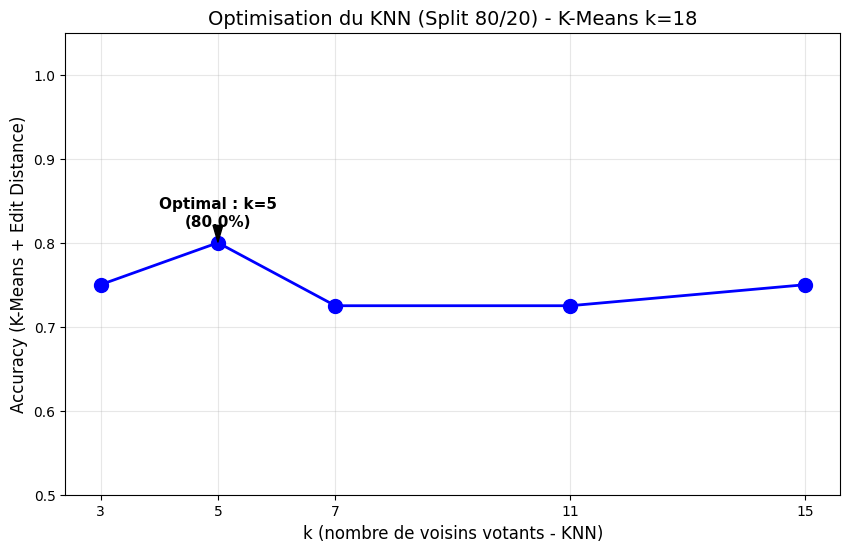


✓ Meilleur k pour le KNN : 5 avec 80.00% de précision


In [35]:
print("============================================================")
print(" Test hyperparamètre k pour k-NN (Méthode Split 80/20)")
print("============================================================")

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATASET_A_TESTER = df_domain1.copy()
BEST_K_KMEANS = 18  # On fixe le k du K-Means (ex: 18 pour le full)

# On isole les répétitions 5 et 6 (comme dans ton code)
df_subset = DATASET_A_TESTER[DATASET_A_TESTER['repetition'].isin([5, 6])].copy()

# ==========================================
# 2. CRÉATION DES IDENTIFIANTS ET SPLIT 80/20
# ==========================================
# Créer un identifiant unique par geste (sujet_digit_repetition)
df_subset['geste_id'] = (df_subset['subject_id'].astype(str) + "_" + 
                         df_subset['digit'].astype(str) + "_" + 
                         df_subset['repetition'].astype(str))

unique_gestes = df_subset['geste_id'].unique()

# Extraction du digit pour stratifier (équilibrer les chiffres)
labels_gestes = [g.split('_')[1] for g in unique_gestes]

# Split 80/20
train_ids, test_ids = train_test_split(unique_gestes, test_size=0.20, random_state=42, stratify=labels_gestes)

df_train = df_subset[df_subset['geste_id'].isin(train_ids)].copy()
df_test = df_subset[df_subset['geste_id'].isin(test_ids)].copy()

print(f"Total gestes: {len(unique_gestes)}")
print(f"Gestes Train (80%): {len(train_ids)} | Gestes Test (20%): {len(test_ids)}")

# ==========================================
# 3. PRÉPARATION DE L'ALPHABET (K-MEANS)
# ==========================================
print(f"\n--- Préparation de l'alphabet (K-Means avec k={BEST_K_KMEANS}) ---")

# (Remplace 'x', 'y', 'z' par 'x_std', etc. si tes données sont standardisées)
X_train_k = df_train[['x', 'y', 'z']].values
kmeans = kMeans_application(X_train_k, BEST_K_KMEANS)

# Traduction en mots (avec include_groups=False pour éviter le texte rouge)
df_train_mots = df_train.groupby(['subject_id', 'digit', 'repetition']).apply(
    lambda g: traduire_en_lettres(g, kmeans), include_groups=False
).reset_index()

df_test_mots = df_test.groupby(['subject_id', 'digit', 'repetition']).apply(
    lambda g: traduire_en_lettres(g, kmeans), include_groups=False
).reset_index()

train_gestures = df_train_mots.to_dict(orient='records')

# ==========================================
# 4. BOUCLE D'OPTIMISATION DU KNN
# ==========================================
k_knn_values = [3, 5, 7, 11, 15]
print(f"\nValeurs de k (KNN) à tester: {k_knn_values}")

results = []

for k_knn in k_knn_values:
    y_true, y_pred = [], []
    
    for _, test_row in df_test_mots.iterrows():
        prediction = knn(test_row.to_dict(), train_gestures, k=k_knn)
        y_true.append(test_row['digit'])
        y_pred.append(prediction)
    
    accuracy = accuracy_score(y_true, y_pred)
    print(f" -> KNN k = {k_knn:<2} | Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    results.append({'k_knn': k_knn, 'accuracy': accuracy})

# ==========================================
# 5. VISUALISATION
# ==========================================
results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
plt.plot(results_df['k_knn'], results_df['accuracy'], 'bo-', linewidth=2, markersize=10)
plt.xlabel('k (nombre de voisins votants - KNN)', fontsize=12)
plt.ylabel('Accuracy (K-Means + Edit Distance)', fontsize=12)
plt.title(f'Optimisation du KNN (Split 80/20) - K-Means k={BEST_K_KMEANS}', fontsize=14)
plt.xticks(k_knn_values)
plt.grid(True, alpha=0.3)

min_acc = results_df['accuracy'].min()
plt.ylim(min(0.5, min_acc - 0.1), 1.05)

best_idx = results_df['accuracy'].idxmax()
best_k = results_df.loc[best_idx, 'k_knn']
best_accuracy = results_df.loc[best_idx, 'accuracy']

plt.annotate(
    f'Optimal : k={best_k}\n({best_accuracy * 100:.1f}%)', 
    xy=(best_k, best_accuracy), 
    xytext=(best_k, best_accuracy + 0.02),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7),
    fontsize=11, fontweight='bold', ha='center'
)

plt.show()

print("\n" + "="*50)
print(f"✓ Meilleur k pour le KNN : {best_k} avec {best_accuracy*100:.2f}% de précision")
print("="*50)

## Test de l'hyperparamètre k pour k-Means

test basé sur 2 répétitions de chaque chiffre par chaque utilisateur (1 répétitions train et 1 pour le test) on récupère les répétitions 5 et 6 (au centre de 1 à 10) pour laisser le temps à l'utilisateur de prendre en main le matériel mais pas trop pour être parfait (représentant un comportement moyen).

Phase d'optimisation tuning hyperparametre : on test la stabilité de l'alphabet symbolique pour un même utilisateur.

Par la suite on va tester la capacité du modèle à reconnaitre les gestes des sujets totalement absents du training (user independent).

Train set: (8340, 10)
Test set: (8423, 10)
Subjects train: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Subjects test: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Digits: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Repetition train : [5] & Repetition test : [6]

Valeurs de k à tester: [10, 12, 14, 16, 18, 20]

--- Test avec k = 10 ---


C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\3671167877.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train_mots = df_train.groupby(['subject_id', 'digit', 'repetition']).apply(
C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\3671167877.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_test_mots = df_test.groupby(['subject_id', 'digit', 'repetition']).apply(


  Mots train: 100, Mots test: 100
  Accuracy: 0.8900 (89.00%)

--- Test avec k = 12 ---


C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\3671167877.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train_mots = df_train.groupby(['subject_id', 'digit', 'repetition']).apply(
C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\3671167877.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_test_mots = df_test.groupby(['subject_id', 'digit', 'repetition']).apply(


  Mots train: 100, Mots test: 100
  Accuracy: 0.9100 (91.00%)

--- Test avec k = 14 ---


...

  Mots train: 100, Mots test: 100
  Accuracy: 0.9300 (93.00%)

--- Test avec k = 18 ---


C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\3671167877.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train_mots = df_train.groupby(['subject_id', 'digit', 'repetition']).apply(
C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\3671167877.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_test_mots = df_test.groupby(['subject_id', 'digit', 'repetition']).apply(


  Mots train: 100, Mots test: 100
  Accuracy: 0.9000 (90.00%)

--- Test avec k = 20 ---


C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\3671167877.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train_mots = df_train.groupby(['subject_id', 'digit', 'repetition']).apply(
C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\3671167877.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_test_mots = df_test.groupby(['subject_id', 'digit', 'repetition']).apply(


  Mots train: 100, Mots test: 100
  Accuracy: 0.8700 (87.00%)

=== RÉSUMÉ DES RÉSULTATS ===
 k  accuracy
10      0.89
12      0.91
14      0.93
16      0.93
18      0.90
20      0.87


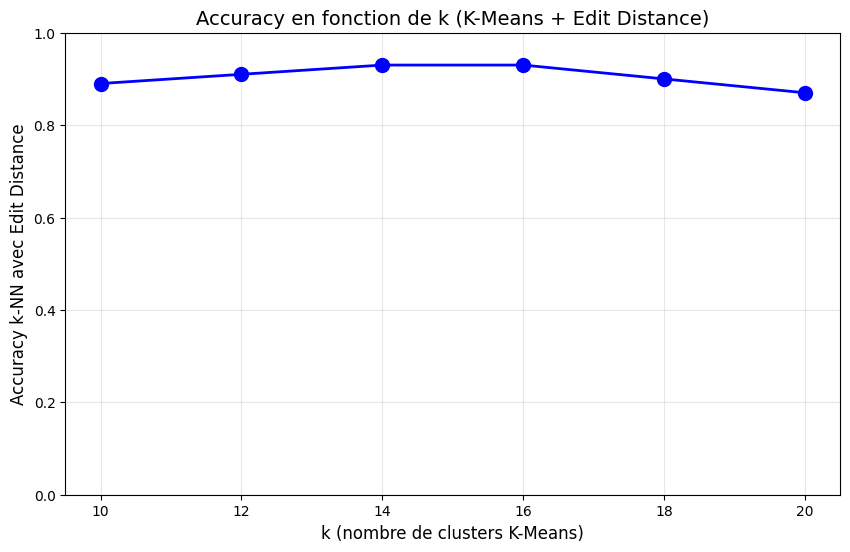


✓ Meilleur k: 14 avec accuracy = 0.9300 (93.00%)


In [21]:
# ============================================================
# Test hyperparamètre k pour K-Means avec Edit Distance
# ============================================================

# 1. Créer les dataframes de train et test
# a faire varier entre df_domain 1, df_domain1_downsampled etc.
# Train: répétitions 5, Test: répétitions 6
df_train = df_domain1[df_domain1['repetition'] == 5].copy()
df_test = df_domain1[df_domain1['repetition'] == 6].copy()

print(f"Train set: {df_train.shape}")
print(f"Test set: {df_test.shape}")
print(f"Subjects train: {sorted(df_train['subject_id'].unique())}")
print(f"Subjects test: {sorted(df_test['subject_id'].unique())}")
print(f"Digits: {sorted(df_test['digit'].unique())}")
print(f"Repetition train : {df_train['repetition'].unique()} & Repetition test : {df_test['repetition'].unique()}")

# 2. Valeurs de k à tester (10 à 20 inclus, pas de 2)
k_values = list(range(10, 21, 2))  # [10, 12, 14, 16, 18, 20]
print(f"\nValeurs de k à tester: {k_values}")

# 3. Boucle de test pour chaque k
results = []

for k in k_values:
    print(f"\n--- Test avec k = {k} ---")
    
    # A. Entraîner K-Means sur les données de train (utilise la fonction existante)
    X_train_k = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = kMeans_application(X_train_k, k)
    
    # B. Traduire les gestes de train en mots (utilise la fonction existante)
    df_train_mots = df_train.groupby(['subject_id', 'digit', 'repetition']).apply(
        lambda g: traduire_en_lettres(g, kmeans)
    ).reset_index()
    
    # C. Traduire les gestes de test en mots
    df_test_mots = df_test.groupby(['subject_id', 'digit', 'repetition']).apply(
        lambda g: traduire_en_lettres(g, kmeans)
    ).reset_index()
    
    print(f"  Mots train: {len(df_train_mots)}, Mots test: {len(df_test_mots)}")
    
    # D. Appliquer k-NN avec Edit Distance (utilise la fonction existante)
    y_true = []
    y_pred = []
    
    # Convertir en liste de dictionnaires pour utiliser la fonction knn existante
    train_gestures = df_train_mots.to_dict(orient='records')
    
    for idx, test_row in df_test_mots.iterrows():
        test_gesture = test_row.to_dict()
        prediction = knn(test_gesture, train_gestures, k=3)
        
        y_true.append(test_row['digit'])
        y_pred.append(prediction)
    
    # E. Calculer l'accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    results.append({'k': k, 'accuracy': accuracy})

# 4. Résultats
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("=== RÉSUMÉ DES RÉSULTATS ===")
print("="*50)
print(results_df.to_string(index=False))

# 5. Visualisation
plt.figure(figsize=(10, 6))
plt.plot(results_df['k'], results_df['accuracy'], 'bo-', linewidth=2, markersize=10)
plt.xlabel('k (nombre de clusters K-Means)', fontsize=12)
plt.ylabel('Accuracy k-NN avec Edit Distance', fontsize=12)
plt.title('Accuracy en fonction de k (K-Means + Edit Distance)', fontsize=14)
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.show()

# 6. Meilleur k
best_idx = results_df['accuracy'].idxmax()
best_k = results_df.loc[best_idx, 'k']
best_accuracy = results_df.loc[best_idx, 'accuracy']
print(f"\n✓ Meilleur k: {best_k} avec accuracy = {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

Split 80/20 for the 5th & 6th repetition of each subject and each digit.

In [22]:
# ============================================================
# Test hyperparamètre k pour K-Means avec Edit Distance
# Split 80/20 basé sur les répétitions 5 et 6
# ============================================================

# 1. Isoler les répétitions 5 et 6
df_subset = df_domain1[df_domain1['repetition'].isin([5, 6])].copy()

print(df_subset['digit'].value_counts())

# Créer un identifiant unique par geste (sujet + digit + repetition)
# pour ne pas mélanger les points d'un même geste
df_subset['geste_id'] = df_subset['subject_id'].astype(str) + "_" + \
                        df_subset['digit'].astype(str) + "_" + \
                        df_subset['repetition'].astype(str)

unique_gestes = df_subset['geste_id'].unique()

# 2. Split 80/20 des identifiants de gestes
# Stratify permet de garder la même proportion de chiffres (0-9) dans train et test
labels_gestes = [g.split('_')[1] for g in unique_gestes] # Extraction du digit pour stratifier
print("Nombre de gestes par chiffre :", Counter(labels_gestes))
train_ids, test_ids = train_test_split(unique_gestes, test_size=0.20, random_state=42,stratify=labels_gestes)

df_train = df_subset[df_subset['geste_id'].isin(train_ids)].copy()
df_test = df_subset[df_subset['geste_id'].isin(test_ids)].copy()

print(f"Total gestes: {len(unique_gestes)}")
print(f"Gestes Train (80%): {len(train_ids)} | Gestes Test (20%): {len(test_ids)}")

# 3. Valeurs de k à tester
k_values = list(range(10, 21, 2))
results = []

for k in k_values:
    print(f"\n--- Test avec k = {k} ---")
    
    # A. Entraîner K-Means sur les coordonnées 3D du train set
    X_train_k = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = kMeans_application(X_train_k, k)
    
    # B. Traduire les gestes de train en mots
    df_train_mots = df_train.groupby(['subject_id', 'digit', 'repetition']).apply(
        lambda g: traduire_en_lettres(g, kmeans)
    ).reset_index()
    
    # C. Traduire les gestes de test en mots
    df_test_mots = df_test.groupby(['subject_id', 'digit', 'repetition']).apply(
        lambda g: traduire_en_lettres(g, kmeans)
    ).reset_index()
    
    # D. Classification k-NN
    y_true, y_pred = [], []
    train_gestures = df_train_mots.to_dict(orient='records')
    
    for _, test_row in df_test_mots.iterrows():
        prediction = knn(test_row.to_dict(), train_gestures, k=3)
        y_true.append(test_row['digit'])
        y_pred.append(prediction)
    
    # E. Calculer l'accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    results.append({'k': k, 'accuracy': accuracy})

    # 4. Résultats
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("=== RÉSUMÉ DES RÉSULTATS ===")
print("="*50)
print(results_df.to_string(index=False))

# 5. Visualisation
plt.figure(figsize=(10, 6))
plt.plot(results_df['k'], results_df['accuracy'], 'bo-', linewidth=2, markersize=10)
plt.xlabel('k (nombre de clusters K-Means)', fontsize=12)
plt.ylabel('Accuracy k-NN avec Edit Distance', fontsize=12)
plt.title('Accuracy en fonction de k (K-Means + Edit Distance)', fontsize=14)
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.show()

# 6. Meilleur k
best_idx = results_df['accuracy'].idxmax()
best_k = results_df.loc[best_idx, 'k']
best_accuracy = results_df.loc[best_idx, 'accuracy']
print(f"\n✓ Meilleur k: {best_k} avec accuracy = {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

digit
8    2193
1    1799
5    1784
4    1760
0    1750
3    1690
9    1644
6    1605
2    1511
7    1027
Name: count, dtype: int64
Nombre de gestes par chiffre : Counter({'0': 20, '1': 20, '2': 20, '3': 20, '4': 20, '5': 20, '6': 20, '7': 20, '8': 20, '9': 20})
Total gestes: 200
Gestes Train (80%): 160 | Gestes Test (20%): 40

--- Test avec k = 10 ---


C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\194468577.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train_mots = df_train.groupby(['subject_id', 'digit', 'repetition']).apply(
C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\194468577.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_test_mots = df_test.groupby(['subject_id', 'digit', 'repetition']).apply(


  Accuracy: 0.9250 (92.50%)

--- Test avec k = 12 ---


C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\194468577.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train_mots = df_train.groupby(['subject_id', 'digit', 'repetition']).apply(
C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\194468577.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_test_mots = df_test.groupby(['subject_id', 'digit', 'repetition']).apply(


  Accuracy: 0.8250 (82.50%)

--- Test avec k = 14 ---


C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\194468577.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train_mots = df_train.groupby(['subject_id', 'digit', 'repetition']).apply(
C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\194468577.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_test_mots = df_test.groupby(['subject_id', 'digit', 'repetition']).apply(


  Accuracy: 0.9000 (90.00%)

--- Test avec k = 16 ---


C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\194468577.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train_mots = df_train.groupby(['subject_id', 'digit', 'repetition']).apply(
C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\194468577.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_test_mots = df_test.groupby(['subject_id', 'digit', 'repetition']).apply(


KeyboardInterrupt: 

## Cross validation (User Independant)


In [ ]:
def split_user(data):

    users = {}
    for gesture in data:
        user_id = gesture['subject_id']
        if user_id not in users:
            users[user_id] = []
        users[user_id].append(gesture)
    return users

gestures_user = split_user(df_mots.to_dict(orient='records'))

for user_id, gestures in gestures_user.items():
    print(f"User {user_id} has {len(gestures)} gestures.")

User 1 has 90 gestures.
User 2 has 10 gestures.
User 3 has 85 gestures.
User 4 has 44 gestures.
User 5 has 90 gestures.
User 6 has 92 gestures.
User 7 has 91 gestures.
User 8 has 85 gestures.
User 9 has 88 gestures.
User 10 has 89 gestures.


: 

Testing on user 1...
Accuracy for user 1: 0.98
Testing on user 2...
Accuracy for user 2: 0.30
Testing on user 3...
Accuracy for user 3: 0.98
Testing on user 4...
Accuracy for user 4: 0.86
Testing on user 5...
Accuracy for user 5: 0.82
Testing on user 6...
Accuracy for user 6: 0.65
Testing on user 7...
Accuracy for user 7: 0.76
Testing on user 8...
Accuracy for user 8: 0.91
Testing on user 9...
Accuracy for user 9: 0.89
Testing on user 10...
Accuracy for user 10: 0.85
 Moyenne des Accuracy: 0.80
Ecart-type des accuracies par utilisateur : 0.19 


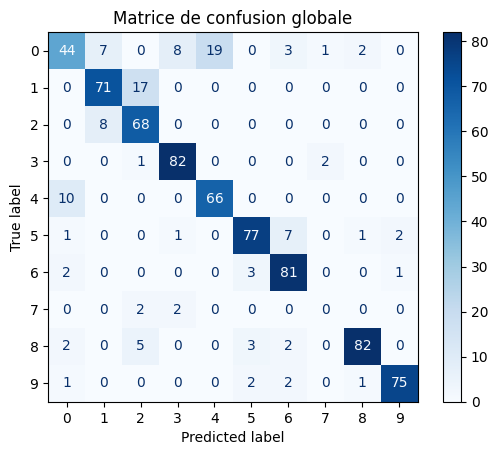

: 

In [ ]:
def cross_validation_user_independent(users, k=3, plot_confusion=True):
    accuracies = []
    all_y_true = []
    all_y_pred = []
    
    for test_user in sorted(users.keys()):
        print(f"Testing on user {test_user}...")

        test_gestures = users[test_user]
        training_gestures = []

        for train_user in users:
            if train_user != test_user:
                training_gestures.extend(users[train_user]) 
        
        y_true = [gesture['digit'] for gesture in test_gestures]
        y_pred = [knn(gesture, training_gestures, k=k) for gesture in test_gestures]


        accur = accuracy_score(y_true, y_pred)
        print(f"Accuracy for user {test_user}: {accur:.2f}")
        accuracies.append(accur)

        all_y_true.extend(y_true)
        all_y_pred.extend(y_pred)
    
    overall_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)

    print(f" Moyenne des Accuracy: {overall_accuracy:.2f}")
    print(f"Ecart-type des accuracies par utilisateur : {std_accuracy:.2f} ")

    if plot_confusion:
        cm = confusion_matrix(all_y_true, all_y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(set(all_y_true)))
        disp.plot(cmap=plt.cm.Blues)
        plt.title("Matrice de confusion globale")
        plt.show()
    
    return overall_accuracy, std_accuracy

accuracy, std_accuracy = cross_validation_user_independent(gestures_user, k=3)


## Cross Validation (User Dependent)

In [ ]:
def split_by_user_and_class(data):
    split_data = {}
    for gesture in data:
        user_id = gesture['subject_id']
        digit = gesture['digit']
        key = (user_id, digit)
        
        if key not in split_data:
            split_data[key] = []
        split_data[key].append(gesture)
    
    return split_data

: 

Fold 1/10...
Accuracy for fold 1: 0.79
Fold 2/10...
Accuracy for fold 2: 0.91
Fold 3/10...
Accuracy for fold 3: 0.97
Fold 4/10...
Accuracy for fold 4: 0.95
Fold 5/10...
Accuracy for fold 5: 0.99
Fold 6/10...
Accuracy for fold 6: 0.97
Fold 7/10...
Accuracy for fold 7: 0.97
Fold 8/10...
Accuracy for fold 8: 0.96
Fold 9/10...
Accuracy for fold 9: 0.96
Fold 10/10...
Accuracy for fold 10: 0.95
 Moyenne des Accuracy: 0.94
Ecart-type des accuracies par fold : 0.05


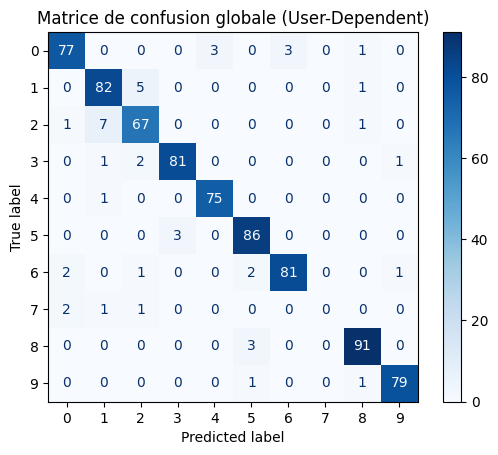

: 

In [ ]:
def cross_validation_user_dependent(data, k=3, plot_confusion=True):
    split_data = split_by_user_and_class(data)
    
    accuracies = []
    all_y_true = [] 
    all_y_pred = []

    users_unique = sorted(list(set([cle[0] for cle in split_data.keys()])))
    numbers_unique = sorted(list(set([cle[1] for cle in split_data.keys()])))

    for fold in range(10):
        print(f"Fold {fold + 1}/10...")
        y_true_fold = []
        y_pred_fold = []
        
        for user in users_unique:
            test_gestures = []
            training_gestures = []

            for digit in numbers_unique:
                key = (user, digit)

                if key not in split_data:
                    continue
                
                samples = split_data[key]

                if fold >= len(samples):
                    continue

                test_sample = samples[fold]
                train_samples = [s for i, s in enumerate(samples) if i != fold]

                test_gestures.append(test_sample)
                training_gestures.extend(train_samples)
            
            if not test_gestures:
                continue

            y_true = [gesture['digit'] for gesture in test_gestures]
            y_pred = [knn(gesture, training_gestures, k=k) for gesture in test_gestures]

            y_true_fold.extend(y_true)
            y_pred_fold.extend(y_pred)
    

        if y_true_fold:
            accur = accuracy_score(y_true_fold, y_pred_fold)
            print(f"Accuracy for fold {fold + 1}: {accur:.2f}")
            accuracies.append(accur)

            all_y_true.extend(y_true_fold)
            all_y_pred.extend(y_pred_fold)

    overall_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)
    print(f" Moyenne des Accuracy: {overall_accuracy:.2f}")
    print(f"Ecart-type des accuracies par fold : {std_accuracy:.2f}")

    if plot_confusion:
        cm = confusion_matrix(all_y_true, all_y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(set(all_y_true)))
        disp.plot(cmap=plt.cm.Blues)
        plt.title("Matrice de confusion globale (User-Dependent)")
        plt.show()
    
    return overall_accuracy, std_accuracy

accuracy_ud, std_accuracy_ud = cross_validation_user_dependent(df_mots.to_dict(orient='records'), k=3)

# DTW

In [ ]:
print("Préparation des données pour le DTW...")
gestures_dtw = []

for index, row in df_domain1_downsampled.iterrows():
    sequence = np.column_stack((row['x'], row['y'], row['z'])).astype(np.float32)

    gestures_dtw.append({
        'subject_id': row['subject_id'],
        'digit': int(row['digit']),
        'sequence': sequence
    })

print(f"{len(gestures_dtw)} séquences prêtes pour le DTW.")

Préparation des données pour le DTW...
36912 séquences prêtes pour le DTW.


: 

In [ ]:
def dtw_multivarie(seq1, seq2):
    """
    Calcule la distance DTW entre deux séquences 3D.
    La distance est calculée indépendamment pour X, Y, et Z, puis additionnée.
    """
    distance_totale = 0
    
    # Boucle sur les 3 dimensions : 0=X, 1=Y, 2=Z
    for dim in range(3):
        # On extrait la courbe de la dimension en cours
        s1 = seq1[:, dim]
        s2 = seq2[:, dim]
        n, m = len(s1), len(s2)
        
        # Initialisation de la matrice des coûts avec l'infini
        dtw_matrix = np.full((n + 1, m + 1), np.inf)
        dtw_matrix[0, 0] = 0
        
        # Remplissage de la matrice (programmation dynamique)
        for i in range(1, n + 1):
            for j in range(1, m + 1):
                # La différence absolue entre les deux points
                cout_local = abs(s1[i - 1] - s2[j - 1])
                # On ajoute le chemin le moins coûteux (Insertion, Suppression, ou Correspondance)
                dtw_matrix[i, j] = cout_local + min(dtw_matrix[i-1, j], 
                                                    dtw_matrix[i, j-1], 
                                                    dtw_matrix[i-1, j-1])
                
        # On ajoute le score final de cette dimension au total
        distance_totale += dtw_matrix[n, m]
        
    return distance_totale/(n+m)


def knn_dtw(test_gesture, train_data, k=3):
    """
    Trouve les k-plus proches voisins en utilisant la distance DTW.
    """
    distances = []
    seq_test = test_gesture['sequence']
    
    for train_gesture in train_data:
        seq_train = train_gesture['sequence']
        
        # Calcul de la distance
        dist = dtw_multivarie(seq_test, seq_train)
        
        # On stocke le couple (distance, chiffre_réel)
        distances.append((dist, train_gesture['digit']))
        
    # Tri du plus proche au plus éloigné
    distances.sort(key=lambda x: x[0])
    
    # On garde les K meilleurs et on fait voter
    voisins_gagnants = [label for distance, label in distances[:k]]
    chiffre_predit = Counter(voisins_gagnants).most_common(1)[0][0]
    
    return chiffre_predit

: 

In [ ]:
print("Lancement de la Cross-Validation User-Independent (DTW)...")
print("Prépare un café, cela va prendre beaucoup de temps !\n")

accuracies = []
all_y_true = []
all_y_pred = []

utilisateurs = sorted(list(set([g['subject_id'] for g in gestures_dtw])))

for sujet_test in utilisateurs:
    
    # --- OPTIONNEL : DÉCOMMENTE LES 2 LIGNES SUIVANTES POUR UN TEST RAPIDE ---
    # if sujet_test > 2:  # Ne teste que les Utilisateurs 1 et 2
    #     break
    
    print(f"👤 Test avec l'utilisateur inconnu n°{sujet_test}...")
    
    # Séparation Train/Test
    test_data = [g for g in gestures_dtw if g['subject_id'] == sujet_test]
    train_data = [g for g in gestures_dtw if g['subject_id'] != sujet_test]
    
    y_true_sujet = [g['digit'] for g in test_data]
    y_pred_sujet = []
    
    # La fameuse barre de progression autour de ta boucle !
    for test_gesture in tqdm(test_data, desc=f"Progression User {sujet_test}"):
        prediction = knn_dtw(test_gesture, train_data, k=3)
        y_pred_sujet.append(prediction)
        
    acc = accuracy_score(y_true_sujet, y_pred_sujet)
    print(f"Accuracy utilisateur {sujet_test} : {acc * 100:.2f}%\n")
    
    accuracies.append(acc)
    all_y_true.extend(y_true_sujet)
    all_y_pred.extend(y_pred_sujet)

# Bilan global (s'affichera à la toute fin)
mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)

print("="*45)
print("BILAN FINAL - DTW USER-INDEPENDENT")
print("="*45)
print(f"Précision moyenne : {mean_acc * 100:.2f}%")
print(f"Écart-type       : {std_acc * 100:.2f}%")

cm = confusion_matrix(all_y_true, all_y_pred, labels=list(range(10)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title("Matrice de confusion - DTW (User Independent)")
plt.show()

Lancement de la Cross-Validation User-Independent (DTW)...
Prépare un café, cela va prendre beaucoup de temps !

👤 Test avec l'utilisateur inconnu n°1.0...


Progression User 1.0: 100%|██████████| 4693/4693 [46:14<00:00,  1.69it/s]  


Accuracy utilisateur 1.0 : 16.77%

👤 Test avec l'utilisateur inconnu n°2.0...


Progression User 2.0: 100%|██████████| 354/354 [03:37<00:00,  1.63it/s]


Accuracy utilisateur 2.0 : 17.80%

👤 Test avec l'utilisateur inconnu n°3.0...


...

Progression User 6.0: 100%|██████████| 4364/4364 [42:14<00:00,  1.72it/s] 


Accuracy utilisateur 6.0 : 13.13%

👤 Test avec l'utilisateur inconnu n°7.0...


Progression User 7.0:  17%|█▋        | 812/4677 [10:03<47:52,  1.35it/s]  


KeyboardInterrupt: 

: 

In [ ]:
def cross_validation_user_dependent_dtw(data, k=3):
    print("🚀 Lancement de la Cross-Validation User-Dependent (DTW)...")
    print("☕ Attention : C'est la méthode la plus longue de tout ton projet. Laisse tourner !\n")

    # 1. On trie tes données 3D avec TA méthode des Tuples
    split_data = {}
    for gesture in data:
        user_id = gesture['subject_id']
        digit = gesture['digit']
        key = (user_id, digit)
        
        if key not in split_data:
            split_data[key] = []
        split_data[key].append(gesture)

    accuracies = []
    all_y_true = [] 
    all_y_pred = []

    # Création des listes uniques
    users_unique = sorted(list(set([cle[0] for cle in split_data.keys()])))
    numbers_unique = sorted(list(set([cle[1] for cle in split_data.keys()])))

    # 2. La boucle des 10 Folds
    for fold in range(10):
        print(f"\n▶️ Fold {fold + 1}/10 en cours...")
        y_true_fold = []
        y_pred_fold = []
        
        # Barre de progression pour voir l'avancement des utilisateurs dans CE fold
        for user in tqdm(users_unique, desc=f"Fold {fold+1}"):
            test_gestures = []
            training_gestures = []

            for digit in numbers_unique:
                key = (user, digit)

                if key not in split_data:
                    continue
                
                samples = split_data[key]

                # Sécurité pour le sous-échantillonnage (remplace leur "if len < 10")
                if fold >= len(samples):
                    continue

                test_sample = samples[fold]
                train_samples = [s for i, s in enumerate(samples) if i != fold]

                test_gestures.append(test_sample)
                training_gestures.extend(train_samples)
            
            if not test_gestures:
                continue

            # --- LA MAGIE EST ICI : On appelle TON knn_dtw ---
            y_true = [gesture['digit'] for gesture in test_gestures]
            y_pred = [knn_dtw(gesture, training_gestures, k=k) for gesture in test_gestures]

            y_true_fold.extend(y_true)
            y_pred_fold.extend(y_pred)
    
        if y_true_fold:
            accur = accuracy_score(y_true_fold, y_pred_fold)
            print(f"   ✅ Accuracy du Fold {fold + 1} : {accur * 100:.2f}%")
            accuracies.append(accur)

            all_y_true.extend(y_true_fold)
            all_y_pred.extend(y_pred_fold)

    # 3. Bilan global
    overall_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)
    
    print("\n" + "="*45)
    print("🏆 BILAN FINAL - DTW USER-DEPENDENT")
    print("="*45)
    print(f"🎯 Moyenne des Accuracy : {overall_accuracy * 100:.2f}%")
    print(f"📉 Ecart-type         : {std_accuracy * 100:.2f}%")

    # 4. Matrice de confusion
    cm = confusion_matrix(all_y_true, all_y_pred, labels=list(range(10)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
    
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap='Greens', ax=ax) # En vert pour marquer le User-Dependent
    plt.title("Matrice de confusion globale (DTW User-Dependent)")
    plt.show()
    
    return overall_accuracy, std_accuracy

# ==========================================
# LANCEMENT OFFICIEL DU TEST 
# (assure-toi que la liste gestes_dtw est bien en mémoire)
# ==========================================
acc_dtw_ud, std_dtw_ud = cross_validation_user_dependent_dtw(gestures_dtw, k=3)

: 